In [1]:
!pip install -q sentence-transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the opener.",
    "The team won the cricket match by chasing the target in 18 overs.",
    "Fielders saved crucial runs near the boundary in the last over.",

    # Cooking
    "The chef added fresh herbs to the pasta sauce for extra flavor.",
    "Baking a cake requires accurate measurements of flour and sugar.",
    "She fried the vegetables in olive oil with garlic and pepper.",

    # Cybersecurity
    "Strong passwords and multi-factor authentication improve account security.",
    "The company detected a phishing attack targeting employee email accounts.",
    "Installing security patches helps prevent malware and ransomware attacks."
]

topics = [
    "Cricket", "Cricket", "Cricket", "Cricket",
    "Cooking", "Cooking", "Cooking",
    "Cybersecurity", "Cybersecurity", "Cybersecurity"
]

df = pd.DataFrame({
    "Sentence No": range(1, 11),
    "Topic": topics,
    "Sentence": sentences
})

df

,Sentence No,Topic,Sentence
0,1,Cricket,The batsman scored a century in the final match.
1,2,Cricket,The bowler delivered a fast yorker to dismiss ...
2,3,Cricket,The team won the cricket match by chasing the ...
3,4,Cricket,Fielders saved crucial runs near the boundary ...
4,5,Cooking,The chef added fresh herbs to the pasta sauce ...
5,6,Cooking,Baking a cake requires accurate measurements o...
6,7,Cooking,She fried the vegetables in olive oil with gar...
7,8,Cybersecurity,Strong passwords and multi-factor authenticati...
8,9,Cybersecurity,The company detected a phishing attack targeti...
9,10,Cybersecurity,Installing security patches helps prevent malw...


In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [5]:
similarity_matrix = cosine_similarity(embeddings, embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i}" for i in range(1, 11)],
    columns=[f"S{i}" for i in range(1, 11)]
)

similarity_df

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
S1,1.000000,0.389233,0.618007,0.371341,-0.043617,0.115161,0.018269,0.010702,0.011343,0.020509
S2,0.389233,1.000000,0.408966,0.399239,0.094680,0.043287,0.057572,-0.036465,0.115335,-0.072889
S3,0.618007,0.408966,1.000000,0.376758,-0.005215,0.074165,0.013467,-0.053208,0.112771,0.023409
S4,0.371341,0.399239,0.376758,1.000000,0.069499,0.059488,0.100012,0.097251,0.030904,0.051445
S5,-0.043617,0.094680,-0.005215,0.069499,1.000000,0.006900,0.388237,-0.000962,0.041229,0.120072
S6,0.115161,0.043287,0.074165,0.059488,0.006900,1.000000,0.031028,-0.008910,0.082321,-0.048558
S7,0.018269,0.057572,0.013467,0.100012,0.388237,0.031028,1.000000,-0.025946,0.118751,-0.019130
S8,0.010702,-0.036465,-0.053208,0.097251,-0.000962,-0.008910,-0.025946,1.000000,0.336328,0.301660
S9,0.011343,0.115335,0.112771,0.030904,0.041229,0.082321,0.118751,0.336328,1.000000,0.173675
S10,0.020509,-0.072889,0.023409,0.051445,0.120072,-0.048558,-0.019130,0.301660,0.173675,1.000000


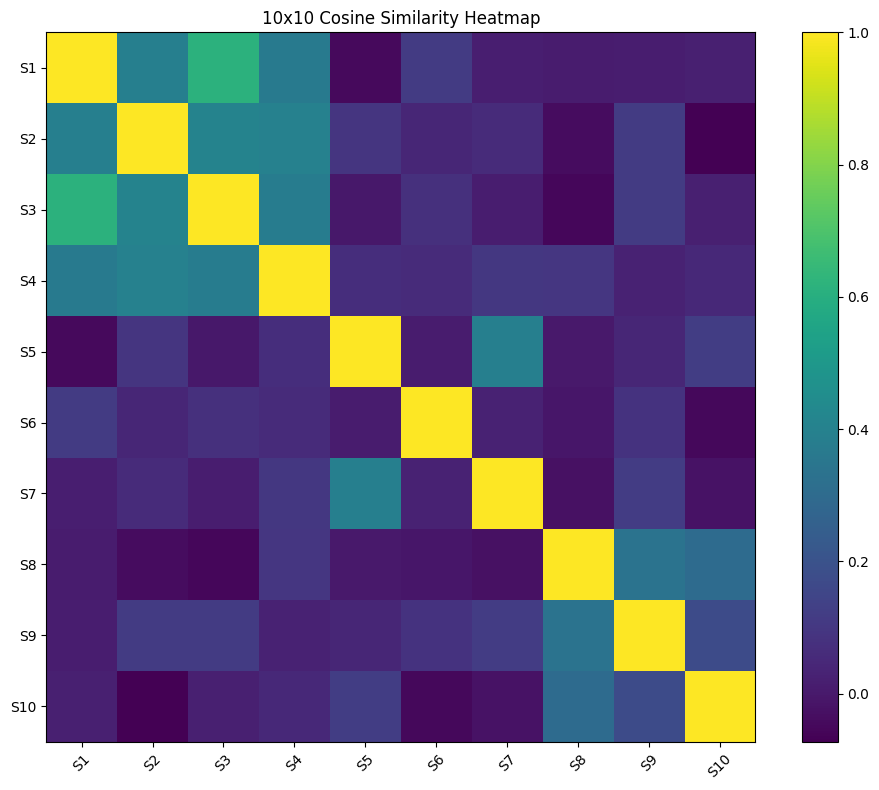

In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, interpolation='nearest')
plt.colorbar()
plt.xticks(range(10), [f"S{i}" for i in range(1, 11)], rotation=45)
plt.yticks(range(10), [f"S{i}" for i in range(1, 11)])
plt.title("10x10 Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

top_2_indices = query_similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_2_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_similarities[idx]:.4f}")
    print("-" * 50)

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679
--------------------------------------------------
Sentence: The team won the cricket match by chasing the target in 18 overs.
Similarity Score: 0.5522
--------------------------------------------------


## Interpretation

The similarity matrix shows that sentences within the same topic tend to have higher cosine similarity than sentences from unrelated topics. The query sentence about wickets and bowling is expected to be closest to cricket-related sentences because the embedding model captures semantic meaning rather than only exact keyword overlap.